In [1]:
!pip install -q wfdb imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.2 MB/s eta 0:00:0000:01


In [2]:
# Import library
import os
import wfdb
import time
import pywt
import random
import importlib
import datetime
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn

from collections import Counter
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.utils import resample, shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, f1_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dropout, LayerNormalization, BatchNormalization, GlobalAveragePooling1D, Dense, Add, Flatten
from tensorflow.keras.layers import DepthwiseConv1D, ReLU, Conv1D, MaxPooling1D 

2026-05-17 16:56:13.711964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779036974.089820      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779036974.209670      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779036975.161688      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779036975.161737      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779036975.161741      57 computation_placer.cc:177] computation placer alr

In [3]:
# Global seed for full reproducibility
SEED = 42
os.environ['PYTHONHASHSEED']      = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'      # forces deterministic GPU ops
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## **1. Preprocessing MIH-BIT Arrhythmia Database**

In [4]:
DATA_PATH = "/kaggle/input/datasets/nthaiann/mih-bih-arrhythmia-database-1-0-0/mit-bih-arrhythmia-database-1.0.0"

In [5]:
ecg_class_dict = {"N": "Normal beat",
                  "L": "Left bundle branch block beat",
                  "R": "Right bundle branch block beat",
                  "e": "Atrial premature beat",
                  "j": "Nodal escape beat", 
                  "A": "Atrial premature beat", 
                  "a": "Aberrated atrial premature beat", 
                  "J": "Nodal premature beat", 
                  "S": "Supraventricular premature beat", 
                  "V": "Premature ventricular contraction", 
                  "E": "Ventricular escape beat", 
                  "F": "Fusion of ventricular and normal beat", 
                  "/": "Paced beat", 
                  "f": "Fusion of paced and normal beat", 
                  "Q": "Unclassifiable beat"}

ecg_class = list(ecg_class_dict.keys())
ecg_classname = list(ecg_class_dict.values())

In [6]:
def denoise(data):
    # Wavelet transform
    coeffs = pywt.wavedec(data=data, wavelet='db5', level=9)
    cA9, cD9, cD8, cD7, cD6, cD5, cD4, cD3, cD2, cD1 = coeffs

    # Threshold denoising
    threshold = (np.median(np.abs(cD1)) / 0.6745) * (np.sqrt(2 * np.log(len(cD1))))
    cD1.fill(0)
    cD2.fill(0)
    
    for i in range(1, len(coeffs) - 2):
        coeffs[i] = pywt.threshold(coeffs[i], threshold)

    # Inverse wavelet transform to obtain the denoised signal
    rdata = pywt.waverec(coeffs=coeffs, wavelet='db5')
    return rdata

In [7]:
def read_preprocessed_data(record_num, X_data, Y_data):
    '''
    record_num (str): the record number (eg. "100")
    X_data (array): list to store ECG segments
    Y_data (array): list to store label
    '''
    record_path = os.path.join(DATA_PATH, record_num)
    
    record = wfdb.rdrecord(record_path, channel_names = ["MLII"])
    annotation = wfdb.rdann(record_path, "atr")
    print(f"Reading record {record_num}")
    
    # Denoising by DWT
    data = record.p_signal.flatten()
    rdata = denoise(data)
    
    # R-peak location
    r_location = annotation.sample
    r_class = annotation.symbol

    # Unstable data before and after removal
    start = 2  # if it creates problem then except will do the job
    end = 3  
    i = start
    j = len(annotation.symbol) - end

    while i < j:
        try:
            beat_type = r_class[i]
            label = ecg_class.index(beat_type)  # when beat is like '+' or other it will go on except loop
            x_train = rdata[r_location[i] - 99:r_location[i] + 201]
            X_data.append(x_train)
            Y_data.append(label)
            i += 1
        except ValueError:
            # print(f'--- When i = {i}, beat type is out of our choise. For example +, [, ! or other')
            i += 1
    
    return X_data, Y_data

In [8]:
data_set = []
label_set = []
record_num = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
              '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', 
              '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', 
              '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', 
              '222', '223', '228', '230', '231', '232', '233', '234'] # 48 readings

for n in record_num:
    try:
        data_set, label_set = read_preprocessed_data(n, data_set, label_set)
    except:
        print(f"-- Skipping record {n}: Does not have MLII")
        continue

Reading record 100
Reading record 101
Reading record 102
-- Skipping record 102: Does not have MLII
Reading record 103
Reading record 104
-- Skipping record 104: Does not have MLII
Reading record 105
Reading record 106
Reading record 107
Reading record 108
Reading record 109
Reading record 111
Reading record 112
Reading record 113
Reading record 114
Reading record 115
Reading record 116
Reading record 117
Reading record 118
Reading record 119
Reading record 121
Reading record 122
Reading record 123
Reading record 124
Reading record 200
Reading record 201
Reading record 202
Reading record 203
Reading record 205
Reading record 207
Reading record 208
Reading record 209
Reading record 210
Reading record 212
Reading record 213
Reading record 214
Reading record 215
Reading record 217
Reading record 219
Reading record 220
Reading record 221
Reading record 222
Reading record 223
Reading record 228
Reading record 230
Reading record 231
Reading record 232
Reading record 233
Reading record 234


In [9]:
print("Total number of segments:", len(data_set))
print("Each segment's length:", len(data_set[0]))

Total number of segments: 104897
Each segment's length: 300


In [10]:
Counter(label_set)

Counter({0: 74658,
         5: 2540,
         9: 7117,
         14: 15,
         12: 3612,
         11: 802,
         4: 229,
         1: 8063,
         6: 150,
         7: 83,
         2: 7244,
         10: 106,
         8: 2,
         13: 260,
         3: 16})

In [11]:
label_aami_class = label_set

for i in range (len(label_set)):
    if 0 <= label_set[i] <= 4:
        label_aami_class[i] = 0 # N
    if 5 <= label_set[i] <= 8:
        label_aami_class[i] = 1 # S
    if 9 <= label_set[i] <= 10:
        label_aami_class[i] = 2 # V
    if label_set[i] == 11:
        label_aami_class[i] = 3 # F
    if 12 <= label_set[i] <= 14:
        label_aami_class[i] = 4 #Q

Counter(label_aami_class)

Counter({0: 90210, 1: 2775, 2: 7223, 4: 3887, 3: 802})

In [12]:
data_set = np.array(data_set).reshape(-1,300)
label_aami_class = np.array(label_aami_class).reshape(-1,1)

ecg_dataset = np.hstack((data_set, label_aami_class))
shuffle(ecg_dataset, random_state = 523)

array([[-0.02939318, -0.02812085, -0.02632843, ..., -0.10248519,
        -0.12711882,  0.        ],
       [-0.1245572 , -0.12678452, -0.12808126, ..., -0.43463512,
        -0.43457934,  0.        ],
       [-0.12896804, -0.14683607, -0.16487344, ...,  1.77065859,
         1.37251906,  0.        ],
       ...,
       [-0.29550159, -0.29268512, -0.28996048, ...,  0.44855269,
         0.47064949,  0.        ],
       [-0.21482597, -0.22006855, -0.22861929, ..., -0.00393732,
        -0.00203792,  1.        ],
       [-0.07242567, -0.07195214, -0.07150747, ..., -0.19869883,
        -0.19919537,  0.        ]])

In [13]:
ecg_dataset.shape

(104897, 301)

## **2. Train-Test Splitting & Class Balancing**

### **2.1. Train-Test Splitting**

In [14]:
ecg_data = ecg_dataset[:, :300]
ecg_label = ecg_dataset[:, 300]

X_train, X_test, y_train, y_test = train_test_split(ecg_data, ecg_label,
                                   random_state=60, 
                                   test_size=0.2, 
                                   shuffle=True)

In [15]:
Counter(y_train.flatten())

Counter({np.float64(0.0): 72225,
         np.float64(2.0): 5747,
         np.float64(1.0): 2217,
         np.float64(4.0): 3086,
         np.float64(3.0): 642})

In [16]:
len(y_train.flatten())

83917

In [17]:
Counter(y_test.flatten())

Counter({np.float64(0.0): 17985,
         np.float64(2.0): 1476,
         np.float64(3.0): 160,
         np.float64(1.0): 558,
         np.float64(4.0): 801})

In [18]:
len(y_test.flatten())

20980

In [19]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
train_data = np.hstack((X_train, y_train))
test_data = np.hstack((X_test, y_test))

### **2.2. Class Balancing by Undersampling and SMOTE-Tomek**

In [20]:
train_data = pd.DataFrame(train_data)

In [21]:
# extracting class 0 and 4 others class
major_class = train_data.loc[(train_data[300] == 0)]
minor_classes = train_data.loc[(train_data[300] != 0)]

In [22]:
# 1. Class 0: Randomly selected 55000 data (RUS)
r_major_class = major_class.sample(n=55000,random_state=42)
r_major_class = r_major_class.to_numpy()

In [23]:
# 2. Class 1, 2, 3, 4: Use SMOTE to oversample upto 55000 
minor_classes = minor_classes.to_numpy()

X_other, y_other = minor_classes[:, :300], minor_classes[:, 300]

sampling_strategy = {cls: 55000 for cls in Counter(y_other).keys()}

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=SEED)
tomek = TomekLinks()
smote_tomek = SMOTETomek(smote=smote, tomek=tomek, random_state=SEED)

X_resampled, y_resampled = smote_tomek.fit_resample(X_other, y_other)

In [24]:
r_minor_classes = np.hstack([X_resampled, y_resampled.reshape(-1,1)])

In [25]:
# Final dataset
final_train_dataset = np.vstack([r_major_class, r_minor_classes])
final_train_dataset = shuffle(final_train_dataset, random_state=42)

X_train = final_train_dataset[:, :300]
y_train = final_train_dataset[:, 300]

# Reshape immediately after splitting
X_train = X_train.reshape(-1, 300, 1)  # ← add this
X_test  = X_test.reshape(-1, 300, 1)   # ← add this

y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

## **3. Attention Mechanism**

In [26]:
import tensorflow as tf
from tensorflow.keras import layers

class ChannelAttention(layers.Layer):
    def __init__(self, filters, ratio=8):
        super(ChannelAttention, self).__init__()
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        self.shared_layer_one = layers.Dense(
            self.filters // self.ratio,
            activation='relu',
            kernel_initializer='he_normal',
            use_bias=True,
            bias_initializer='zeros'
        )

        self.shared_layer_two = layers.Dense(
            self.filters,
            kernel_initializer='he_normal',
            use_bias=True,
            bias_initializer='zeros'
        )

    def call(self, inputs):
        # Avg Pool
        avg_pool = tf.reduce_mean(inputs, axis=1)  # (batch, channels)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)

        # Max Pool
        max_pool = tf.reduce_max(inputs, axis=1)    # (batch, channels)
        max_pool = self.shared_layer_one(max_pool)
        max_pool = self.shared_layer_two(max_pool)

        # Combine
        attention = avg_pool + max_pool
        attention = tf.nn.sigmoid(attention)

        # Reshape to (batch, 1, channels)
        attention = tf.expand_dims(attention, axis=1)

        return inputs * attention

## **4. Main Model**

In [27]:
def build_model(max_sequence_length, num_channels):
    input_sequence = Input(shape=(max_sequence_length, num_channels))

    # ── Block 1 ──────────────────────────────────────────────────────────────
    x = Conv1D(filters=16, kernel_size=21, strides=1, padding='same', activation='relu')(input_sequence)
    x = BatchNormalization()(x)
    x = ChannelAttention(16, 8)(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)
    
    # ── Block 2 ──────────────────────────────────────────────────────────────
    x = Conv1D(filters=32, kernel_size=23, strides=1, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = ChannelAttention(32, 8)(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)
    
    # ── Block 3 ──────────────────────────────────────────────────────────────
    x = DepthwiseConv1D(kernel_size=25, strides=1, padding='same',
                        use_bias=False)(x)
    x = Conv1D(filters=64, kernel_size=1, strides=1, padding='same',
               use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = ChannelAttention(64, 8)(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)
    
    # ── Block 4 ──────────────────────────────────────────────────────────────
    x = DepthwiseConv1D(kernel_size=27, strides=1, padding='same',
                        use_bias=False)(x)
    x = Conv1D(filters=128, kernel_size=1, strides=1, padding='same',
               use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = ChannelAttention(128, 8)(x)

    # Output layer
    x = Flatten()(x)
    output = Dense(units=5, activation='softmax')(x)

    # Create the model
    model = Model(inputs=input_sequence, outputs=output)

    return model

In [28]:
model = build_model(max_sequence_length = 300, num_channels = 1)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0015)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

I0000 00:00:1779037459.233521      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779037459.239869      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 300, 16)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention               │ (None, 300, 16)        │            82 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 32)        │        11,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_1             │ (None, 150, 32)        │           292 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv1d                │ (None, 75, 32)         │           800 │
│ (DepthwiseConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 75, 64)         │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_2             │ (None, 75, 64)         │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv1d_1              │ (None, 38, 64)         │         1,728 │
│ (DepthwiseConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 38, 128)        │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_3             │ (None, 38, 128)        │         4,240 │
│ (ChannelAttention)              │                        │             

 Total params: 55,923 (218.45 KB)

 Trainable params: 55,443 (216.57 KB)

 Non-trainable params: 480 (1.88 KB)

## **5. Training**

In [30]:
project_path = "/kaggle/working/"

logdir = os.path.join(
    project_path,
    "logs",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

model_path = os.path.join(
    project_path,
    "best_model.keras"
)

In [31]:
if os.path.exists(model_path):
    print('Model already exists at filepath, loading...')
    model = tf.keras.models.load_model(filepath=model_path)
else:
    print('Model not found, building and training...')

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=logdir, histogram_freq=1)

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='auto',
        patience=15,
        restore_best_weights=True
    )

    callback_list = [tensorboard_callback, early_stopping]

    history = model.fit(
        X_train, y_train,
        epochs=60,
        batch_size=128,
        validation_split=0.15,
        callbacks=callback_list, 
    )

    model.save(filepath=model_path)

Model not found, building and training...
Epoch 1/60


2026-05-17 17:04:23.019760: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1779037468.547357     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


1827/1827 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9309 - loss: 0.1886

2026-05-17 17:05:00.642028: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


1827/1827 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9309 - loss: 0.1886 - val_accuracy: 0.9836 - val_loss: 0.0484
Epoch 2/60
1827/1827 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9848 - loss: 0.0459 - val_accuracy: 0.9892 - val_loss: 0.0315
Epoch 3/60
1827/1827 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9897 - loss: 0.0318 - val_accuracy: 0.9906 - val_loss: 0.0269
Epoch 4/60
1827/1827 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9914 - loss: 0.0259 - val_accuracy: 0.9917 - val_loss: 0.0249
Epoch 5/60
1827/1827 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9931 - loss: 0.0219 - val_accuracy: 0.9920 - val_loss: 0.0248
Epoch 6/60
1827/1827 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9939 - loss: 0.0180 - val_accuracy: 0.9914 - val_loss: 0.0263
Epoch 7/60
1827/1827 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.9948 - loss: 0.0161 - val_accuracy: 0.9921 - val_loss: 0.0269
Epoch 8/60
1827/1827 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - accuracy: 0.9954 - loss: 0.01

## **6. Evaluating** 

In [32]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print('Training Accuracy: %.2f, Test Accuracy: %.2f' % (train_acc*100, test_acc*100))
print('Training Loss: %.2f, Test Loss: %.2f' % (train_loss*100, test_loss*100))

2026-05-17 17:35:29.071724: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-05-17 17:36:05.427821: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Training Accuracy: 99.98, Test Accuracy: 99.06
Training Loss: 0.11, Test Loss: 7.68


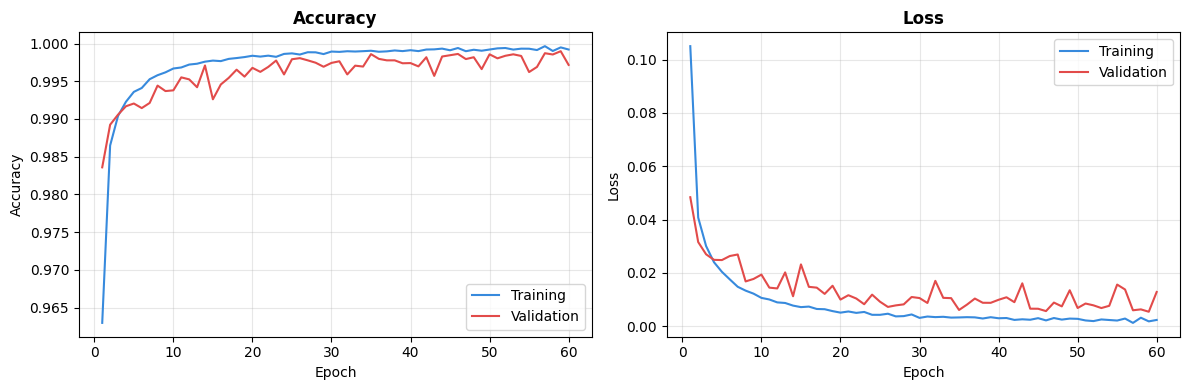

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs, history.history['accuracy'],
             label='Training', color='#378ADD', linewidth=1.5)
axes[0].plot(epochs, history.history['val_accuracy'],
             label='Validation', color='#E24B4A', linewidth=1.5)
axes[0].set_title('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs, history.history['loss'],
             label='Training', color='#378ADD', linewidth=1.5)
axes[1].plot(epochs, history.history['val_loss'],
             label='Validation', color='#E24B4A', linewidth=1.5)
axes[1].set_title('Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# Per class accuracy printing function
def _report(TN, FP, FN, TP):
    TPR = TP/(TP+FN) if (TP+FN)!=0 else 0
    TNR = TN/(TN+FP) if (TN+FP)!=0 else 0
    PPV = TP/(TP+FP) if (TP+FP)!=0 else 0
    
    report = {'Sensitivity (%)': TPR*100,
              'Specificity (%)': TNR*100,
              'F1 Score (%)': 2*100*(PPV*TPR)/(PPV+TPR),
              'Per Class Accuracy (%)': (TP+TN)*100/(TP+FP+FN+TN)
             }
    return report

def multi_classification_report(y_test, y_pred, labels=None, encoded_labels=True, as_frame=False):
    conf_labels = None if encoded_labels else labels

    conf_mat = multilabel_confusion_matrix(y_test, y_pred, labels=conf_labels)
    report = dict()
    if labels == None:
        counter = np.arange(len(conf_mat))
    else:
        counter = labels

    for i, name in enumerate(counter):
        TN, FP, FN, TP = conf_mat[i].ravel()
        report[name] = _report(TN, FP, FN, TP)

    if as_frame:
        return pd.DataFrame(report)
    return report

In [35]:
# Per-class performance
labels = ['N', 'S', 'V', 'F', 'Q']
y_pred = np.argmax(model.predict(X_test), axis=-1)
multi_classification_report(y_test, y_pred, labels=labels, encoded_labels=True, as_frame=True)

656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


,N,S,V,F,Q
Sensitivity (%),99.399500,93.548387,97.967480,85.625000,99.875156
Specificity (%),97.996661,99.701303,99.769278,99.855908,99.990089
F1 Score (%),99.532320,91.498685,97.472194,83.792049,99.812851
Per Class Accuracy (%),99.199237,99.537655,99.642517,99.747378,99.985701


In [36]:
macro_f1 = f1_score(y_test, y_pred, average='macro') * 100

print('Macro F1-score: %.2f' % (macro_f1))

Macro F1-score: 94.42


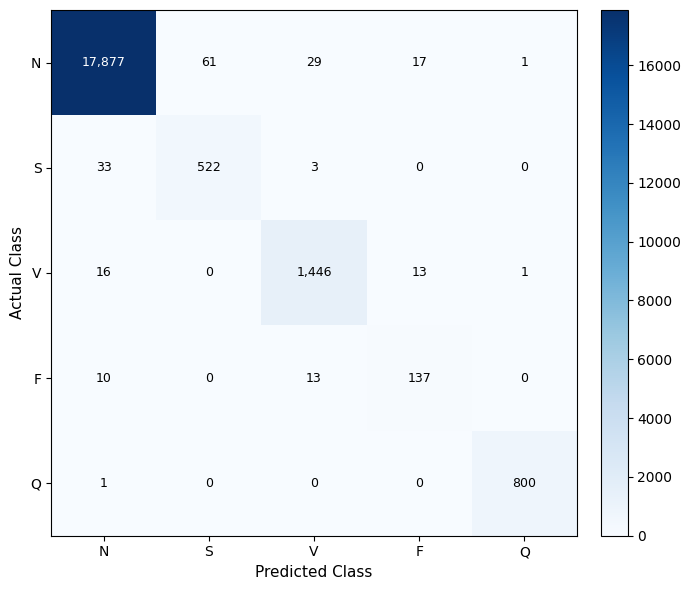

In [37]:
# Confusion matrix
CLASS_NAMES  = ['N', 'S', 'V', 'F', 'Q']
cm_full = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_full, cmap='Blues')

for i in range(5):
    for j in range(5):
        val        = cm_full[i, j]
        text_color = 'white' if val > cm_full.max() * 0.5 else 'black'
        ax.text(j, i, f'{val:,}',
                ha='center', va='center',
                fontsize=9, color=text_color)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(CLASS_NAMES, fontsize=10)
ax.set_yticklabels(CLASS_NAMES, fontsize=10)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('Actual Class',    fontsize=11)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_5class.png',
            dpi=300, bbox_inches='tight')
plt.show()

## **7. Model size & Inference time**

In [38]:
model.save('/kaggle/working/best_model.keras')
model_size_bytes = os.path.getsize('/kaggle/working/best_model.keras')
model_size_kb    = model_size_bytes / 1024
model_size_mb    = model_size_bytes / (1024 ** 2)

print(f"KB    : {model_size_kb:.2f} KB")
print(f"MB    : {model_size_mb:.4f} MB")

KB    : 776.21 KB
MB    : 0.7580 MB


In [39]:
# Compile model call as a graph
@tf.function
def predict_fn(x):
    return model(x, training=False)

single_beat = tf.constant(X_test[0:1], dtype=tf.float32)

# Warmup — tf.function compiles on first call
for _ in range(50):
    _ = predict_fn(single_beat)

# Time
N_RUNS = 200
times  = []

for _ in range(N_RUNS):
    start = time.perf_counter()
    _ = predict_fn(single_beat)
    end   = time.perf_counter()
    times.append((end - start) * 1000)

times = np.array(times)
print(f"Mean : {np.mean(times):.3f} ms")
print(f"Std  : {np.std(times):.3f} ms")
print(f"Min  : {np.min(times):.3f} ms")

Mean : 1.952 ms
Std  : 0.125 ms
Min  : 1.732 ms


In [40]:
with tf.device('/CPU:0'):
    single_beat_cpu = tf.constant(X_test[0:1], dtype=tf.float32)

    @tf.function
    def predict_cpu(x):
        return model(x, training=False)

    # Warmup
    for _ in range(50):
        _ = predict_cpu(single_beat_cpu)

    times_cpu = []
    for _ in range(200):
        start = time.perf_counter()
        _     = predict_cpu(single_beat_cpu)
        end   = time.perf_counter()
        times_cpu.append((end - start) * 1000)

times_cpu = np.array(times_cpu)
print(f"CPU Mean : {np.mean(times_cpu):.3f} ms")
print(f"CPU Min  : {np.min(times_cpu):.3f} ms")

CPU Mean : 2.577 ms
CPU Min  : 2.149 ms
